In [6]:
import os, time, random
import numpy as np
import pandas as pd
import cv2, torch
from tqdm.auto import tqdm
import shutil as sh

from IPython.display import Image, clear_output
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
%%time

%pip install -U pycocotools
!git clone https://github.com/ultralytics/yolov5
%pip install -qr yolov5/requirements.txt
%cp yolov5/requirements.txt ./

Note: you may need to restart the kernel to use updated packages.
Cloning into 'yolov5'...
remote: Enumerating objects: 17968, done.
remote: Counting objects: 100% (119/119), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 17968 (delta 95), reused 51 (delta 51), pack-reused 17849 (from 3)
Receiving objects: 100% (17968/17968), 17.10 MiB | 3.33 MiB/s, done.
Resolving deltas: 100% (12226/12226), done.
ERROR: Operation cancelled by user
^C
Note: you may need to restart the kernel to use updated packages.
CPU times: user 626 ms, sys: 133 ms, total: 759 ms
Wall time: 1min 4s


In [4]:
drive_path = "./data"
img_h, img_w, num_channels = (380, 676, 3)
df = pd.read_csv(f'{drive_path}/train_solution_bounding_boxes (1).csv')
df.rename(columns={'image': 'image_id'}, inplace=True)
df['image_id'] = df['image_id'].apply(lambda x: x.split('.')[0])
df['x_center'] = (df['xmin'] + df['xmax']) / 2
df['y_center'] = (df['ymin'] + df['ymax']) / 2
df['w'] = df['xmax'] - df['xmin']
df['h'] = df['ymax'] - df['ymin']
df['classes'] = 0
df['x_center'] = df['x_center'] / img_w
df['w'] = df['w'] / img_w
df['y_center'] = df['y_center'] / img_h
df['h'] = df['h'] / img_h
df.head()

,image_id,xmin,ymin,xmax,ymax,x_center,y_center,w,h,classes
0,vid_4_1000,281.259045,187.035071,327.727931,223.225547,0.450434,0.539817,0.068741,0.095238,0
1,vid_4_10000,15.163531,187.035071,120.329957,236.430180,0.100217,0.557191,0.155572,0.129987,0
2,vid_4_10040,239.192475,176.764801,361.968162,236.430180,0.444645,0.543678,0.181621,0.157014,0
3,vid_4_10020,496.483358,172.363256,630.020260,231.539575,0.833213,0.531451,0.197540,0.155727,0
4,vid_4_10060,16.630970,186.546010,132.558611,238.386422,0.110347,0.559122,0.171491,0.136422,0


In [8]:
index = list(set(df.image_id))
image = random.choice(index)
print("Image ID: %s" %(image))
img = cv2.imread(f'{drive_path}/training_images/{image}.jpg')
img.shape

Image ID: vid_4_10520


(380, 676, 3)

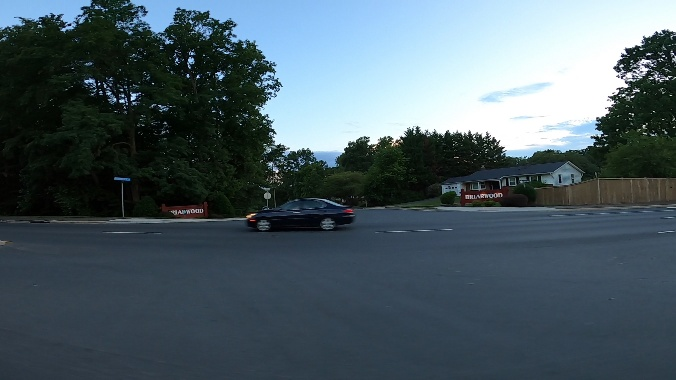

In [9]:
image = random.choice(index)
Image(filename=f'{drive_path}/training_images/{image}.jpg', width=600)

In [ ]:
source = 'training_images'
if True:
    for fold in [0]:
        val_index = index[len(index)*fold//5:len(index)*(fold+1)//5]
        for name, mini in tqdm(df.groupby('image_id')):
            if name in val_index:
                path2save = f'{drive_path}/val2017'
            else:
                path2save = f'{drive_path}/train2017'
            if not os.path.exists('./data/images/tmp/convertor/fold{}/labels'.format(fold)+path2save):
                os.makedirs('./data/images/tmp/convertor/fold{}/labels'.format(fold)+path2save)
            with open('./data/images/tmp/convertor/fold{}/labels'.format(fold)+path2save+f'/{name}.txt', 'w+') as f:
                row = mini[['classes', 'x_center', 'y_center', 'w', 'h']].astype(float).values
                row = row.astype(str)
                for j in range(len(row)):
                    text = ' '.join(row[j])
                    f.write(text + '\n')
            if not os.path.exists('./data/images/tmp/convertor/fold{}/images'.format(fold)+path2save):
                os.makedirs('./data/images/tmp/convertor/fold{}/images'.format(fold)+path2save)
                sh.copy(f'{drive_path}/{source}/{name}.jpg', './data/images/tmp/convertor/fold{}/images'.format(fold)+path2save+f'/{name}.jpg')

  0%|          | 0/355 [00:00<?, ?it/s]

In [ ]:
#!python train.py --batch 2 --epochs 1 --data ../input/yolov5-config/car.yaml --cfg ../input/yolov5-config/yolov5s.yaml --weights yolov5s.pt --name yolov5s_results --img 380

In [17]:
!python yolov5/detect.py --weights yolov5/yolov5s.pt --img 640 --conf 0.4 --source ./data/training_images/

detect: weights=['yolov5/yolov5s.pt'], source=./data/training_images/, data=yolov5/data/coco128.yaml, imgsz=[640, 640], conf_thres=0.4, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=yolov5/runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-484-g70b964b6 Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1650 with Max-Q Design, 3718MiB)

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
image 1/1001 /home/kaming/Work/data-science/jupyter/data/training_images/vid_4_1000.jpg: 384x640 1 car, 16.9ms
image 2/1001 /home/kaming/Work/data-science/jupyter/data/training_images/vid_4_10000.jpg: 384x640 1 car, 13.1ms
image 3/1001 /home/kaming/Work/data-science/jupyter/da

In [18]:
predicted_files = []
for (dirpath, dirnames, filenames) in os.walk("./yolov5/runs/detect/exp"):
    predicted_files.extend(filenames)
print(predicted_files)

['vid_4_17000.jpg', 'vid_4_4060.jpg', 'vid_4_19400.jpg', 'vid_4_14080.jpg', 'vid_4_15000.jpg', 'vid_4_11340.jpg', 'vid_4_16400.jpg', 'vid_4_8700.jpg', 'vid_4_7520.jpg', 'vid_4_6440.jpg', 'vid_4_26620.jpg', 'vid_4_14840.jpg', 'vid_4_17800.jpg', 'vid_4_12000.jpg', 'vid_4_26220.jpg', 'vid_4_22280.jpg', 'vid_4_13800.jpg', 'vid_4_15080.jpg', 'vid_4_3220.jpg', 'vid_4_14740.jpg', 'vid_4_1820.jpg', 'vid_4_3600.jpg', 'vid_4_20240.jpg', 'vid_4_22160.jpg', 'vid_4_12260.jpg', 'vid_4_5800.jpg', 'vid_4_9700.jpg', 'vid_4_19460.jpg', 'vid_4_4540.jpg', 'vid_4_14960.jpg', 'vid_4_12360.jpg', 'vid_4_26640.jpg', 'vid_4_22660.jpg', 'vid_4_28880.jpg', 'vid_4_29740.jpg', 'vid_4_13300.jpg', 'vid_4_960.jpg', 'vid_4_16080.jpg', 'vid_4_14560.jpg', 'vid_4_19840.jpg', 'vid_4_4180.jpg', 'vid_4_6160.jpg', 'vid_4_22800.jpg', 'vid_4_30020.jpg', 'vid_4_11920.jpg', 'vid_4_14380.jpg', 'vid_4_23060.jpg', 'vid_4_26200.jpg', 'vid_4_2480.jpg', 'vid_4_20820.jpg', 'vid_4_27160.jpg', 'vid_4_17520.jpg', 'vid_4_22380.jpg', 'vid_4_

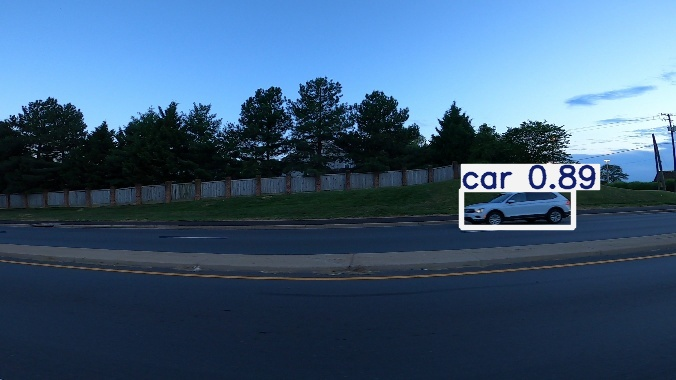

In [25]:
Image(filename=f'yolov5/runs/detect/exp/{random.choice(predicted_files)}')

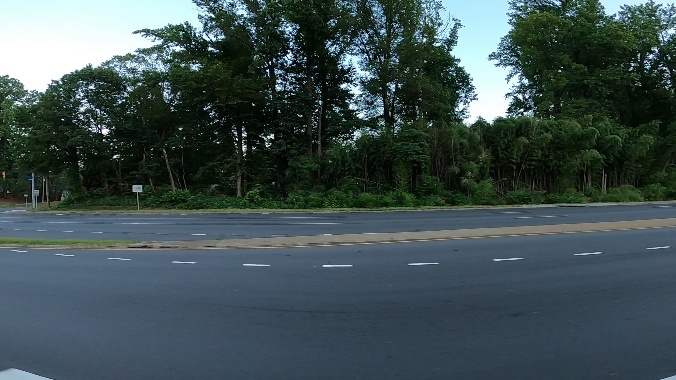

In [26]:
Image(filename=f'yolov5/runs/detect/exp/{random.choice(predicted_files)}')

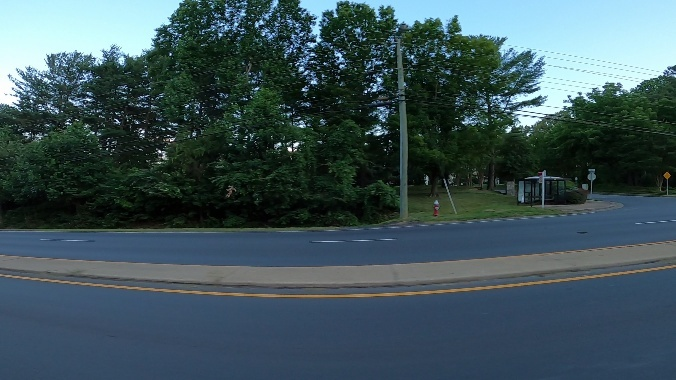

In [27]:
Image(filename=f'yolov5/runs/detect/exp/{random.choice(predicted_files)}')

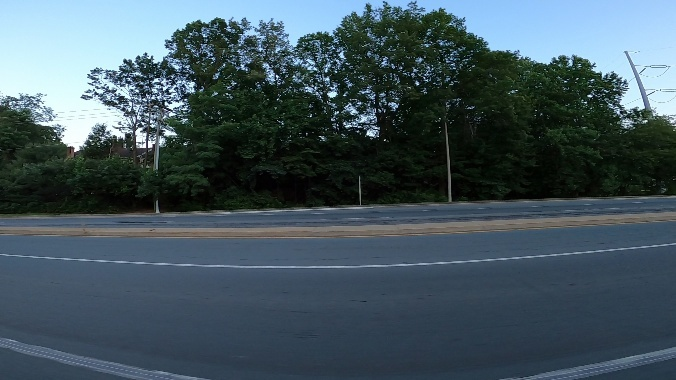

In [28]:
Image(filename=f'yolov5/runs/detect/exp/{random.choice(predicted_files)}')

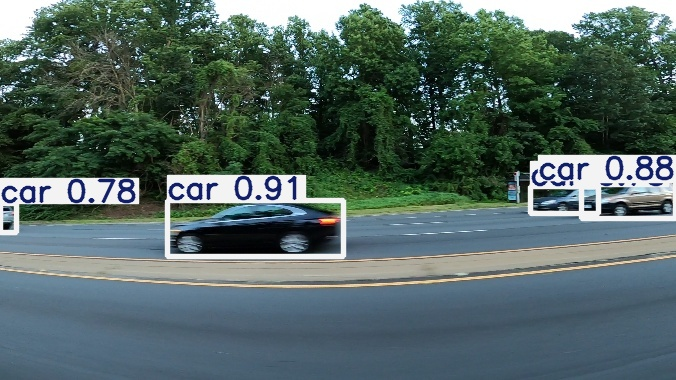

In [29]:
Image(filename=f'yolov5/runs/detect/exp/{random.choice(predicted_files)}')